In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
data_path = '../imdc_2026/data'
disease = 'dengue'
df = pd.read_csv(f'{data_path}/{disease}.csv.gz')

df.head()

,geocode,date,casos,epiweek,uf,macroregional_geocode,regional_geocode,uf_code,target_city,train_1,target_1,train_2,target_2,train_3,target_3,train_4,target_4,disease
0,3301900,2010-01-03,5,201001,RJ,3312,33006,33,False,True,False,True,False,True,False,True,False,dengue
1,1504505,2010-01-03,0,201001,PA,1512,15014,15,False,True,False,True,False,True,False,True,False,dengue
2,1503077,2010-01-03,0,201001,PA,1511,15008,15,False,True,False,True,False,True,False,True,False,dengue
3,2106409,2010-01-03,0,201001,MA,2110,21006,21,False,True,False,True,False,True,False,True,False,dengue
4,3135704,2010-01-03,0,201001,MG,3103,31024,31,False,True,False,True,False,True,False,True,False,dengue


In [4]:
geocodes = [2931350, 2933307, 2302503, 3119401, 3549805,
           3541406, 1200401, 1200203, 1716109, 4113700, 4103701, 4104808,
            5201405, 5102637, 5215231]

len(geocodes)

15

In [5]:
regs = []
sizes =[] 
for geo in geocodes: 

    #print(geo)
    reg = df.loc[df.geocode == geo].regional_geocode.values[0]

    regs.append(reg)
    sizes.append(len(df.loc[df.regional_geocode == reg].geocode.unique()))

df_s = pd.DataFrame()

df_s['geocode'] = geocodes
df_s['regional_geocode'] = regs
df_s['n_cities'] = sizes

df_s.head()


,geocode,regional_geocode,n_cities
0,2931350,29026,13
1,2933307,29028,19
2,2302503,23023,45
3,3119401,31035,8
4,3549805,35155,20


<Axes: >

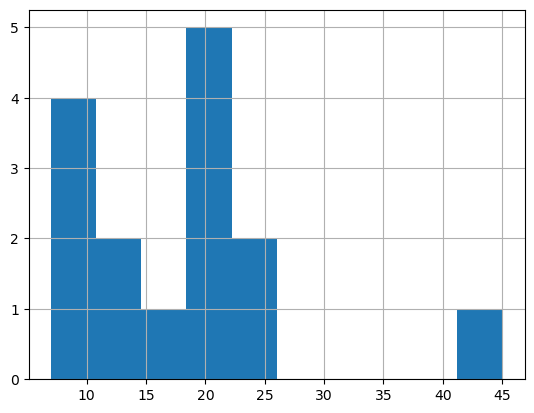

In [6]:
df_s.n_cities.hist()

In [25]:
df_geo = df.loc[df.geocode.isin(geocodes)][['geocode', 'date', 'casos']]
df_geo['year'] = pd.to_datetime(df_geo.date).dt.year
df_geo.head()

,geocode,date,casos,year
1001,4113700,2010-01-03,14,2010
1196,1200203,2010-01-03,4,2010
1418,1200401,2010-01-03,632,2010
1846,1716109,2010-01-03,16,2010
2298,3541406,2010-01-03,4,2010


In [28]:
df_agg = df_geo[['year', 'geocode', 'casos']].groupby(['year', 'geocode']).sum().reset_index()

df_agg.head()

,year,geocode,casos
0,2010,1200203,58
1,2010,1200401,34133
2,2010,1716109,666
3,2010,2302503,407
4,2010,2931350,1410


In [29]:
df_agg[['geocode', 'casos']].groupby('geocode').median()

,casos
geocode,
1200203,1028.0
1200401,1802.0
1716109,224.0
2302503,386.0
2931350,533.0
2933307,381.0
3119401,996.0
3541406,2336.0
3549805,17467.0
